In [253]:
import numpy as np

import matplotlib.pyplot as plt
plt.style.use('figure_style.mplstyle')
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.axes import Axes
from matplotlib.image import AxesImage

from astropy.table import Table
from astropy.table import vstack as tvstack

import glob

from scipy.stats import binned_statistic_2d, binned_statistic, percentileofscore

%matplotlib inline

def colorbar(ax: Axes, im: AxesImage):
    """
    Add a color bar aligned to `im` neater than `fig.colorbar(im)`.
    https://stackoverflow.com/a/39938019/8954109
    """

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="4%", pad=0.05)

    return ax.figure.colorbar(im, cax=cax, orientation="vertical")


In [3]:
tmass = Table.read('fardisk_rgbtargets_all.fits')
print(tmass.colnames)

['designation', 'ra', 'dec', 'jmag', 'e_jmag', 'hmag', 'e_hmag', 'kmag', 'e_kmag', 'qflg', 'glon', 'glat', '_3_6mag', 'e_3_6mag', '_4_5mag', 'e_4_5mag', 'ebv', 'ak', 'jk0', 'h0', 'mirtype', 'aktype', 'gaia_dist', 'gaia_sourceid', 'gaia_ra', 'gaia_dec', 'gaia_pmra', 'gaia_pmra_error', 'gaia_pmdec', 'gaia_pmdec_error', 'gaia_parallax', 'gaia_parallax_error', 'gaia_gmag', 'gaia_bpmag', 'gaia_rpmag', 'brightnei']


In [99]:
lon_rng = [-60,60]
lat_rng = [-15,15]

im_onsky, xe, ye, bn = binned_statistic_2d(tmass['glon'], tmass['glat'], tmass['glon'], statistic='count', 
                                           bins=[120,25], range=[lon_rng,lat_rng])

/var/folders/g9/0lndh9c56xz5yrl_6t6z1wn40000gn/T/ipykernel_20669/3309518250.py:1: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(im_onsky).T, origin='upper', aspect='auto',


(-15.0, 15.0)

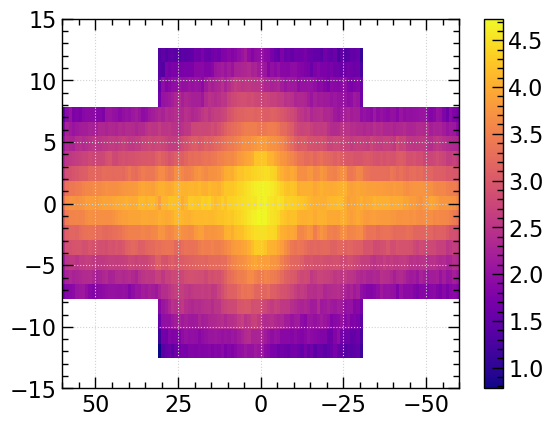

In [101]:
plt.imshow(np.log10(im_onsky).T, origin='upper', aspect='auto',
           extent=[lon_rng[0],lon_rng[1],lat_rng[0],lat_rng[1]])
plt.colorbar()
plt.xlim(np.flip(lon_rng))
plt.ylim(lat_rng)

# Recreate some of David's plots
To make sure I'm parsing the file correctly

In [103]:
gd = np.logical_and.reduce([abs(tmass['glon']-4.0) < 0.25])
h_rng = [6,18]
b_rng = [-13,13]
h_nbins = 75
b_nbins = 75

im_h_b, xe, ye, bn = binned_statistic_2d(tmass['hmag'][gd], tmass['glat'][gd], tmass['ra'][gd], 
                                         statistic='count', range=[h_rng,b_rng], bins=[h_nbins,b_nbins])


/var/folders/g9/0lndh9c56xz5yrl_6t6z1wn40000gn/T/ipykernel_20669/3129449681.py:1: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(im_h_b).T, aspect='auto',


(-13.0, 13.0)

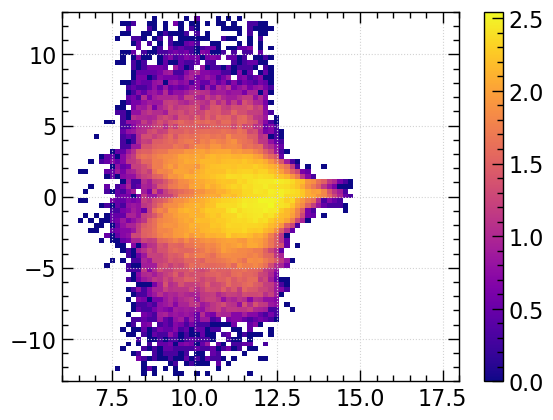

In [105]:
plt.imshow(np.log10(im_h_b).T, aspect='auto', 
           extent=[h_rng[0],h_rng[1],b_rng[0],b_rng[1]])
plt.colorbar()
plt.xlim(h_rng)
plt.ylim(b_rng)

# Which of the populations I've run so far best match 2MASS?

Ah fuck, I didn't include Gaia Gmag so I could check for XP availability 

I used 0.001 deg^2 for the synthetic footprint. If I can math correctly, that corresponds to a box with sides 0.032 deg (=1.92 arcmin). The "pixels" I'm using are 2x1 deg, or 2 deg^2 in area, or 2000 times larger. So I need to multiply the counts by 2000 to get a fairer comparison, and also make sure the 2MASS stars are being selected in a 2x1 deg box.

/var/folders/g9/0lndh9c56xz5yrl_6t6z1wn40000gn/T/ipykernel_20669/3810589174.py:21: RuntimeWarning: divide by zero encountered in log10
  _=ax.imshow(np.log10(im_h_b).T, aspect='auto',
/var/folders/g9/0lndh9c56xz5yrl_6t6z1wn40000gn/T/ipykernel_20669/3810589174.py:49: RuntimeWarning: divide by zero encountered in log10
  _=ax.imshow(np.log10(starcount_scale_factor*im_h_b).T, aspect='auto',


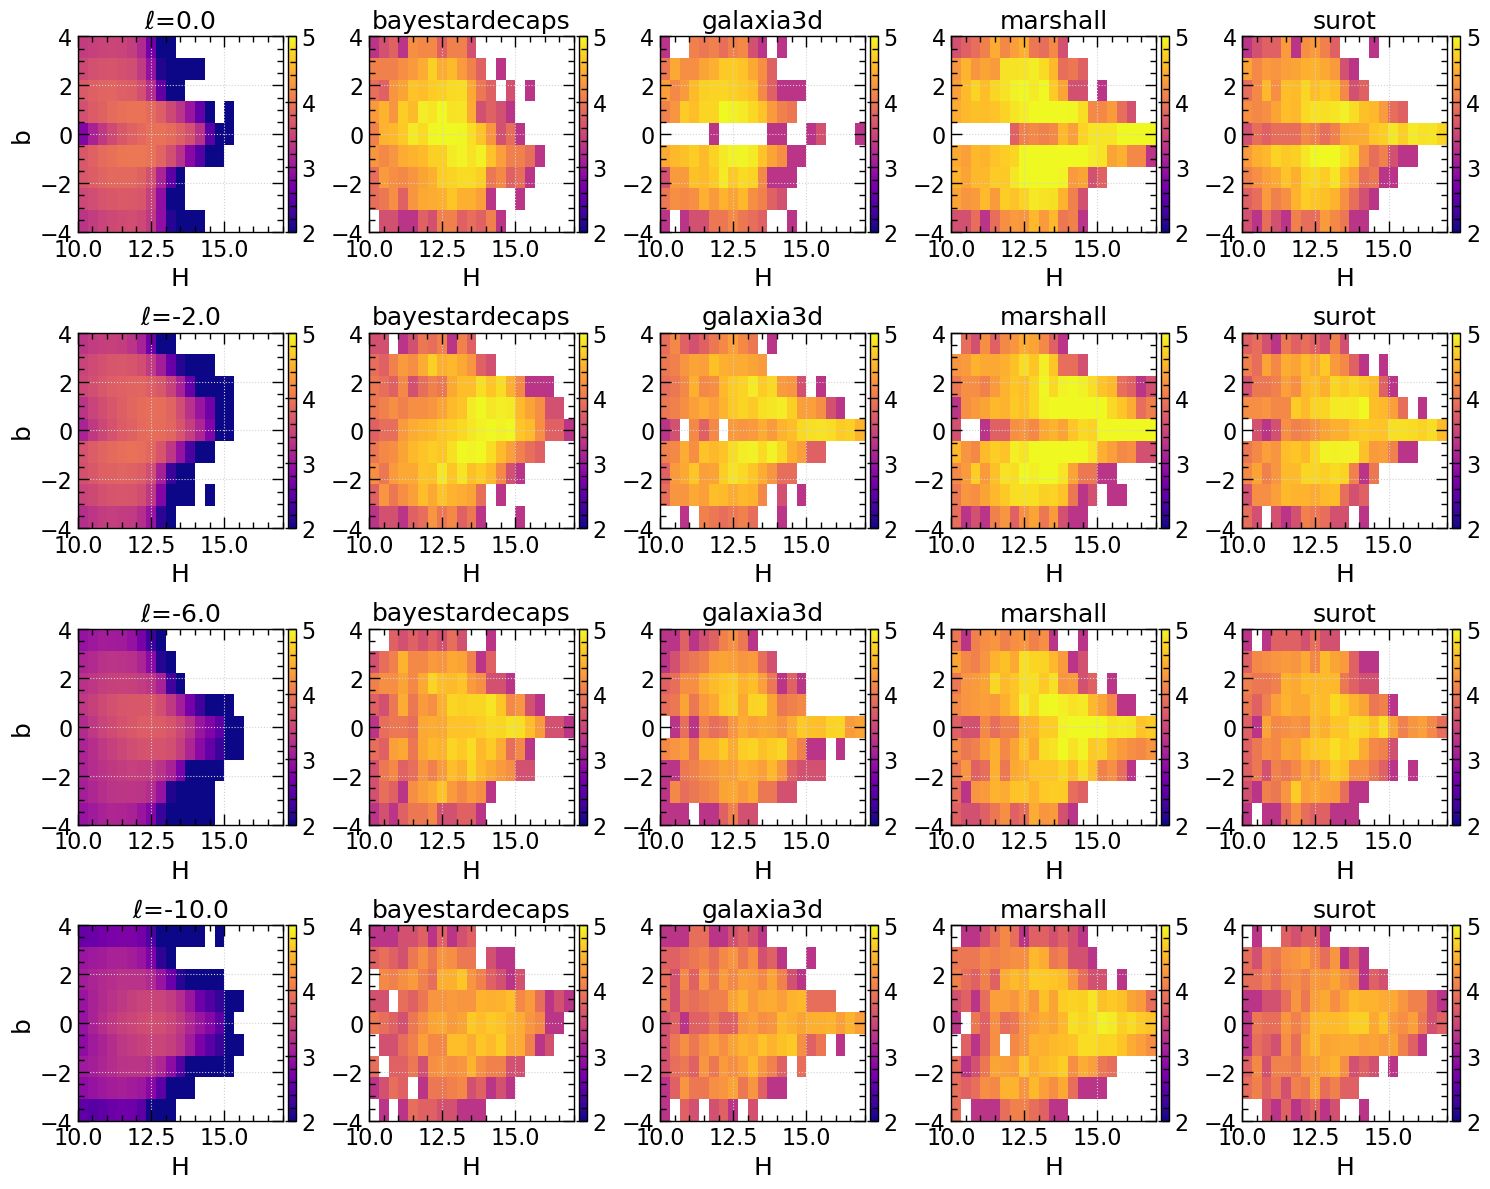

In [294]:
model_configs = np.array(['hge_gums_bayestardecaps','hge_gums_galaxia3d',
                          'hge_gums_marshall','hge_gums_surot'])
test_glon = [0.0, -2.0, -6.0, -10.0] #-20 to +20, even numbers
h_rng = [10,17]
b_rng = [-4,4]
h_nbins = 21
b_nbins = 9
vmin = 2
vmax = 5
low_logg_cut = 2.2
starcount_scale_factor = 2000. #Ratio between area of "pixel" size and actual simulated footprint

fig, axs = plt.subplots(ncols=5, nrows=len(test_glon), figsize=(15,3*len(test_glon)))

for i_glon, this_glon in enumerate(test_glon):
    #Real data
    gd = np.logical_and.reduce([abs(tmass['glon']-test_glon[i_glon]) < 1.0])
    im_h_b, xe, ye, bn = binned_statistic_2d(tmass['hmag'][gd], tmass['glat'][gd], tmass['ra'][gd], 
                                             statistic='count', range=[h_rng,b_rng], bins=[h_nbins,b_nbins])
    ax = axs[i_glon,0]
    _=ax.imshow(np.log10(im_h_b).T, aspect='auto',
                extent=[h_rng[0],h_rng[1],b_rng[0],b_rng[1]],
                interpolation=None, vmin=vmin, vmax=vmax)
    colorbar(ax, _)
    ax.set_xlim(h_rng)
    ax.set_ylim(b_rng)
    ax.set_title(r'$\ell$={}'.format(test_glon[i_glon]))
    ax.set_xlabel('H')
    ax.set_ylabel('b')

    count=0
    for this_config in model_configs:
        this_outputdir = '/Users/gailzasowski/Dropbox/Documents/science/synthpop/outputfiles/' + this_config + '/'
        these_files = glob.glob(this_outputdir + '*_l' + str(test_glon[i_glon]) + '*csv')
        #print(these_files)
        for i_file in range(len(these_files)):
            this_file = these_files[i_file]
            dat0 = Table.read(this_file, format='csv')
            if i_file == 0:
                dat = dat0.copy()
            else:
                dat = tvstack([dat,dat0])
            
        #Make H-b plot
        gd = np.logical_and.reduce([dat['logg'] < low_logg_cut])
        im_h_b, xe, ye, bn = binned_statistic_2d(dat['2MASS_H'][gd], dat['b'][gd], dat['b'][gd], 
                                                 statistic='count', range=[h_rng,b_rng], bins=[h_nbins,b_nbins])
        ax = axs[i_glon,count+1]
        _=ax.imshow(np.log10(starcount_scale_factor*im_h_b).T, aspect='auto',
                    extent=[h_rng[0],h_rng[1],b_rng[0],b_rng[1]],
                    interpolation=None, vmin=vmin, vmax=vmax)
        colorbar(ax, _)
        ax.set_xlim(h_rng)
        ax.set_ylim(b_rng)
        ax.set_title(str.split(this_config,'_')[2])
        ax.set_xlabel('H')
   
        count=count+1

fig.tight_layout()
fig.savefig('compare_model_hmag_vs_lat.pdf', bbox_inches='tight')

- We're only going to have XP-based log(g) estimates for the brightest stars? With H<13 or so?

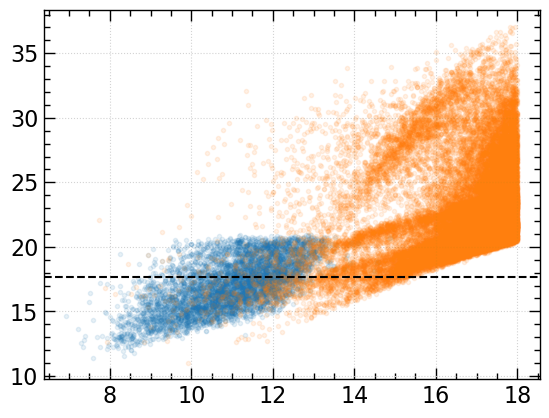

In [303]:
_=plt.plot(tmass['hmag'][::1000], tmass['gaia_gmag'][::1000], '.', alpha=0.1)
_=plt.plot(dat['2MASS_H'], dat['Gaia_G_EDR3'], '.', alpha=0.1)
plt.axhline(y=17.65, ls='--', color='k')

# Test some targeting!

H, log(g), mu_l, dereddened color, extinction ...

Might have to be (l,b)-dependent, but avoid that as much as possible?

What l is the R=3.5 tangent point at? $\pm$24.6$^\circ$, I think.

What |b| corresponds to |Z|=0.5 kpc at the far solar circle? 1.9$^\circ$, I think. So 3.8$^\circ$ for |Z|=1 kpc.

Compute "far disk" probability

In [285]:
#Define criteria
# - remove foreground
max_h = 15.5
min_h = 10.0
max_jk0 = 99.
min_jk0 = 0.5
max_logg = 2.2
min_logg = -99.
#extinction (from RJCE) close to CSFD? Or in top X%ile of the sightline?
min_ext_perc = 60.0

#Run criteria combos on each model config

#Plots: 
# - fraction of far-disk/total stars vs H-mag
# - histogram of R_GC for total sample (and some l-range subdivisions)

/var/folders/g9/0lndh9c56xz5yrl_6t6z1wn40000gn/T/ipykernel_20669/2605627008.py:48: RuntimeWarning: invalid value encountered in divide
  ax.plot(be[1::], np.divide(hist_fd,hist))
/var/folders/g9/0lndh9c56xz5yrl_6t6z1wn40000gn/T/ipykernel_20669/2605627008.py:60: RuntimeWarning: invalid value encountered in divide
  ax.plot(be[1::], np.divide(hist_fd,hist))
/var/folders/g9/0lndh9c56xz5yrl_6t6z1wn40000gn/T/ipykernel_20669/2605627008.py:73: RuntimeWarning: invalid value encountered in divide
  ax.plot(be[1::], np.divide(hist_fd,hist))
/var/folders/g9/0lndh9c56xz5yrl_6t6z1wn40000gn/T/ipykernel_20669/2605627008.py:86: RuntimeWarning: invalid value encountered in divide
  ax.plot(be[1::], np.divide(hist_fd,hist))


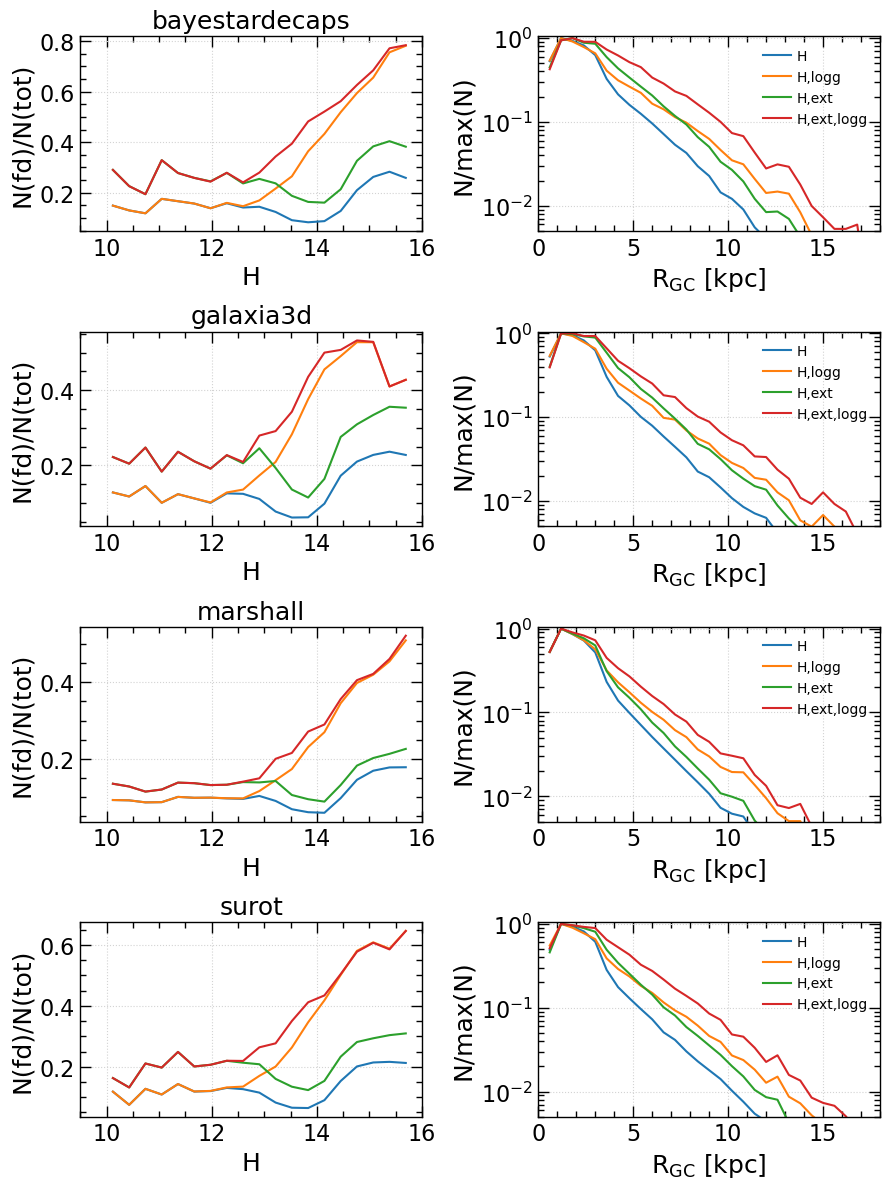

In [305]:
model_configs = np.array(['hge_gums_bayestardecaps','hge_gums_galaxia3d',
                          'hge_gums_marshall','hge_gums_surot'])
extinction_column = np.array(['E(B-V)','E(B-V)','A_Ks','A_Ks'])

fig, axs = plt.subplots(nrows=len(model_configs), ncols=2, figsize=(9,3*len(model_configs)))

h_rng = [min_h-0.5,max_h+0.5]
h_nbins = 21
rgc_rng = [0,18]
rgc_nbins = 30

for i_config, this_config in enumerate(model_configs):
    this_outputdir = '/Users/gailzasowski/Dropbox/Documents/science/synthpop/outputfiles/' + this_config + '/'
    these_files = glob.glob(this_outputdir + '*_l*csv')
    n_pixels = len(these_files)
    extinction_perc = np.full((n_pixels,3), fill_value=np.nan)
    #print(these_files)
    #Read each pixel and compute pixel-level ("neighbor") properties
    for i_file in range(len(these_files)):
        this_file = these_files[i_file]
        dat0 = Table.read(this_file, format='csv')
        observable = np.logical_and.reduce([dat0['2MASS_H'] > min_h, dat0['2MASS_H'] < max_h])
        dat0 = dat0[observable]
        perc_of_ext = percentileofscore(dat0[extinction_column[i_config]],dat0[extinction_column[i_config]])
        dat0['local_ext_perc'] = perc_of_ext
        if i_file == 0:
            dat = dat0.copy()
        else:
            dat = tvstack([dat,dat0])
    rgc = np.sqrt(dat['x']**2 + dat['y']**2)
   
    #Various criteria
    not_foreground = (dat['Dist'] > 6.0)
    in_h_range = np.logical_and.reduce([dat['2MASS_H'] > min_h, dat['2MASS_H'] < max_h])
    low_logg = (dat['logg'] < max_logg)
    high_extinction = (dat['local_ext_perc'] > min_ext_perc)
    far_disk = np.logical_and.reduce([dat['x'] > 0, rgc > 3.5, abs(dat['z']) < 1.0])
    inner_midplane = np.logical_and.reduce([abs(dat['b']) < 0.5, 
                                            np.logical_or.reduce([dat['l'] < 10.0, dat['l'] > 350.])])
    
    #Random selection in H-band
    gd = np.logical_and.reduce([not_foreground, in_h_range])
    gd_fd = np.logical_and.reduce([not_foreground, in_h_range, far_disk])

    hist, be, bn = binned_statistic(dat['2MASS_H'][gd], rgc[gd], statistic='count', range=h_rng, bins=h_nbins)
    hist_fd, be, bn = binned_statistic(dat['2MASS_H'][gd_fd], rgc[gd_fd], statistic='count', range=h_rng, bins=h_nbins)
    ax = axs[i_config,0]
    ax.plot(be[1::], np.divide(hist_fd,hist))
    
    hist, be, bn = binned_statistic(rgc[gd], rgc[gd], statistic='count', range=rgc_rng, bins=rgc_nbins)
    ax = axs[i_config,1]
    ax.plot(be[1::], hist/float(np.max(hist)), label='H')
    
    #Low logg
    gd = np.logical_and.reduce([not_foreground, in_h_range, low_logg])
    gd_fd = np.logical_and.reduce([not_foreground, in_h_range, low_logg, far_disk])
    hist, be, bn = binned_statistic(dat['2MASS_H'][gd], rgc[gd], statistic='count', range=h_rng, bins=h_nbins)
    hist_fd, be, bn = binned_statistic(dat['2MASS_H'][gd_fd], rgc[gd_fd], statistic='count', range=h_rng, bins=h_nbins)
    ax = axs[i_config,0]
    ax.plot(be[1::], np.divide(hist_fd,hist))
    
    hist, be, bn = binned_statistic(rgc[gd], rgc[gd], statistic='count', range=rgc_rng, bins=rgc_nbins)
    ax = axs[i_config,1]
    ax.plot(be[1::], hist/float(np.max(hist)), label='H,logg')

    #High extinction
    gd = np.logical_and.reduce([not_foreground, in_h_range, high_extinction])
    gd_fd = np.logical_and.reduce([not_foreground, in_h_range, high_extinction, far_disk])
    
    hist, be, bn = binned_statistic(dat['2MASS_H'][gd], rgc[gd], statistic='count', range=h_rng, bins=h_nbins)
    hist_fd, be, bn = binned_statistic(dat['2MASS_H'][gd_fd], rgc[gd_fd], statistic='count', range=h_rng, bins=h_nbins)
    ax = axs[i_config,0]
    ax.plot(be[1::], np.divide(hist_fd,hist))
    
    hist, be, bn = binned_statistic(rgc[gd], rgc[gd], statistic='count', range=rgc_rng, bins=rgc_nbins)
    ax = axs[i_config,1]
    ax.plot(be[1::], hist/float(np.max(hist)), label='H,ext')

    #High extinction & low logg
    gd = np.logical_and.reduce([not_foreground, in_h_range, low_logg, high_extinction])
    gd_fd = np.logical_and.reduce([not_foreground, in_h_range, low_logg, high_extinction, far_disk])

    hist, be, bn = binned_statistic(dat['2MASS_H'][gd], rgc[gd], statistic='count', range=h_rng, bins=h_nbins)
    hist_fd, be, bn = binned_statistic(dat['2MASS_H'][gd_fd], rgc[gd_fd], statistic='count', range=h_rng, bins=h_nbins)
    ax = axs[i_config,0]
    ax.plot(be[1::], np.divide(hist_fd,hist))
    ax.set_xlim(h_rng)
    ax.set_xlabel('H')
    ax.set_ylabel('N(fd)/N(tot)')
    ax.set_title(str.split(this_config,'_')[-1])
    
    hist, be, bn = binned_statistic(rgc[gd], rgc[gd], statistic='count', range=rgc_rng, bins=rgc_nbins)
    ax = axs[i_config,1]
    ax.plot(be[1::], hist/float(np.max(hist)), label='H,ext,logg')
    ax.set_xlim(rgc_rng)
    ax.set_ylim([5e-3,1.05])
    ax.set_yscale('log')
    ax.set_xlabel(r'R$_{\rm GC}$ [kpc]')
    ax.set_ylabel('N/max(N)')
    ax.legend()
    
    #break

fig.tight_layout()
fig.savefig('compare_targeting_cuts.pdf')

In [299]:
print(dat.colnames)

['pop', 'iMass', 'age', 'Fe/H_initial', 'Mass', 'In_Final_Phase', 'Dist', 'l', 'b', 'vr_bc', 'mul', 'mub', 'x', 'y', 'z', 'U', 'V', 'W', 'VR_LSR', 'A_Ks', 'logL', 'logTeff', 'logg', 'Fe/H_evolved', 'log_radius', 'phase', 'Gaia_G_EDR3', 'Gaia_BP_EDR3', 'Gaia_RP_EDR3', '2MASS_J', '2MASS_H', '2MASS_Ks', 'IRAC_3.6', 'IRAC_4.5']
